# Post processing VPSC model

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import matflow as mf

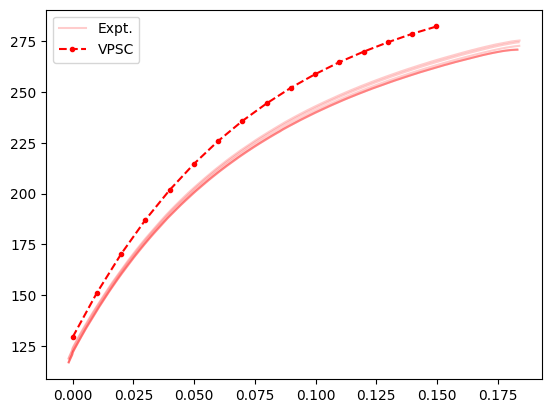

In [24]:
# Quick calibration of parameters by using VPSC from command line:
# module use --append /mnt/eps01-rds/Fonseca-Lightform/shared/software/modulefiles
# module load vpsc/8.0.0
# navigate to tension_VPSC_Al_2026-03-09_220456/execute/t_1/
# $VPSC
# This runs a quick VPSC simulation and produces STR_STR.OUT.
# Plot stress-strain result from this here and compare to your expt.
# change parameters and repeat until model close to expt. (follow red example below)
    
def read_STR_STR_OUT(STR_STR_OUT):
    Evm = []
    Svm = []
    with open(STR_STR_OUT, 'r') as VPSC_results:
        for line in VPSC_results:
            inc = line.split()
            try:
                Evm.append(float(inc[0]))
                Svm.append(float(inc[1]))
            except:
                pass # header line
    Evm = np.array(Evm)
    Svm = np.array(Svm)
    return Evm, Svm
            

Evm, Svm = read_STR_STR_OUT("tension_VPSC_Al_2026-03-09_221113/execute/t_1/STR_STR.OUT")
plt.plot(Evm, Svm, '.--', color='r', label="VPSC")
plt.legend();

### Convert $\dot{F}$ for DAMASK to $L$ for VPSC:
$L = \dot{F} \cdot F^{-1}$

In [3]:
np.set_printoptions(suppress=True)
dot_F = np.array([[0.01, 0.00, 0.00],
                  [0.00, -0.005, 0.00],
                  [0.00, 0.00, -0.005]
                           ])
print(dot_F.shape)
target_vel_grad = dot_F @ dot_F.T
target_vel_grad

(3, 3)


array([[0.0001  , 0.      , 0.      ],
       [0.      , 0.000025, 0.      ],
       [0.      , 0.      , 0.000025]])

In [29]:


workflow = mf.Workflow("tension_VPSC_Al_2026-03-09_221113")

oris_response = workflow.tasks.simulate_orientations_loading_vpsc.elements[0].iterations[0].outputs.orientations_response.value

print(oris_response.keys())
print(oris_response['volume_data'].keys())


dict_keys(['volume_data'])
dict_keys(['avg_equivalent_strain', 'avg_equivalent_stress', 'avg_strain', 'avg_stress', 'avg_temperature', 'time', 'taylav', 'workav', 'workrate1', 'workrate2', 'O'])


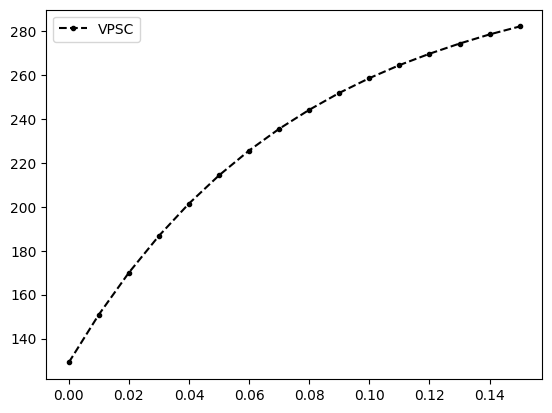

In [28]:

VPSC_strain = np.array(oris_response['volume_data']['avg_strain']['data'])
VPSC_stress = np.array(oris_response['volume_data']['avg_stress']['data'])

plt.plot(VPSC_strain[:,0,0], VPSC_stress[:,0,0], '.--', color='k', label=f"VPSC")
plt.legend();
